<a href="https://colab.research.google.com/github/tejasai1/ai-ml-projects/blob/main/multimodal-caption-detection/image_caption_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Load the exported NDJSON file
records = []
with open("image_caption_labeled_dataset.ndjson", "r") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print(f"Total records loaded: {len(records)}")
print(f"\nKeys in each record:")
print(list(records[0].keys()))

Total records loaded: 30

Keys in each record:
['data_row', 'media_attributes', 'metadata_fields', 'projects']


In [2]:
# Get project ID dynamically
project_id = list(records[0]['projects'].keys())[0]
print(f"Project ID: {project_id}")

# Look at first record's label structure
first_label = records[0]['projects'][project_id]['labels'][0]
print("\nAnnotations structure:")
print(json.dumps(first_label['annotations'], indent=2))

Project ID: cmpg6n408083307xf0rqteil6

Annotations structure:
{
  "objects": [],
  "classifications": [
    {
      "feature_id": "cmpu8w3j80008356ztor6oua8",
      "feature_schema_id": "cmpg6vf7a0qrn07wlbnxg8iu3",
      "name": "Caption Accuracy",
      "value": "caption_accuracy",
      "radio_answer": {
        "feature_id": "cmpu8w3j80007356z9xyzlsp6",
        "feature_schema_id": "cmpg6vf7a0qrs07wl57y8bv8x",
        "name": "Inaccurate",
        "value": "inaccurate",
        "classifications": []
      }
    },
    {
      "feature_id": "cmpu8wwz3000a356znn4bva4o",
      "feature_schema_id": "cmpg6vf7c0qs507wl9jaz8jzx",
      "name": "Detailed Level",
      "value": "detail_level",
      "radio_answer": {
        "feature_id": "cmpu8wwz30009356ztr2i0nt3",
        "feature_schema_id": "cmpg6vf7c0qs807wl7maw6gki",
        "name": "Insufficient",
        "value": "insufficient",
        "classifications": []
      }
    },
    {
      "feature_id": "cmpu8x5kk000c356z07qrsd8w",
     

In [3]:
project_id = list(records[0]['projects'].keys())[0]

rows = []

for record in records:
    global_key = record['data_row']['global_key']
    category = global_key.split('_')[0]  # animals, food, sports etc

    label = record['projects'][project_id]['labels'][0]
    seconds = label['performance_details_v2']['seconds_to_label']

    classifications = label['annotations']['classifications']

    label_dict = {}
    for cls in classifications:
        dimension_name = cls['name']
        answer_name = cls['radio_answer']['name']
        label_dict[dimension_name] = answer_name

    rows.append({
        'image_id':              global_key,
        'category':              category,
        'caption_accuracy':      label_dict.get('Caption Accuracy', 'Unknown'),
        'hallucination_type':    label_dict.get('Visual Hallucination Type', 'Unknown'),
        'detail_level':          label_dict.get('Detailed Level', 'Unknown'),
        'overall_quality':       label_dict.get('Overall Quality', 'Unknown'),
        'seconds_to_label':      seconds,
    })

df = pd.DataFrame(rows)

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 10 rows:")
print(df.head(10).to_string())

Dataset shape: (30, 7)

First 10 rows:
      image_id category    caption_accuracy        hallucination_type  detail_level overall_quality  seconds_to_label
0  animals_002  animals          Inaccurate      Wrong Color or Count  Insufficient        Rejected               520
1  animals_001  animals            Accurate                      None    Sufficient        Approved                24
2  kitchen_001  kitchen          Inaccurate      Wrong Color or Count  Insufficient        Rejected                87
3  kitchen_002  kitchen            Accurate                      None    Sufficient        Approved                28
4     food_004     food          Inaccurate  Wrong Action or Activity    Sufficient        Rejected               109
5  kitchen_003  kitchen  Partially Accurate  Wrong Action or Activity    Sufficient  Needs Revision                62
6   people_002   people          Inaccurate    Wrong Spatial Relation  Insufficient        Rejected                52
7     food_001   

In [4]:
total = len(df)

# Count distributions
accuracy_counts     = df['caption_accuracy'].value_counts()
hallucination_counts = df['hallucination_type'].value_counts()
quality_counts      = df['overall_quality'].value_counts()
detail_counts       = df['detail_level'].value_counts()
category_counts     = df.groupby(['category', 'caption_accuracy']).size().unstack(fill_value=0)

# Key metrics
total_accurate        = accuracy_counts.get('Accurate', 0)
total_partial         = accuracy_counts.get('Partially Accurate', 0)
total_inaccurate      = accuracy_counts.get('Inaccurate', 0)
total_hallucinations  = total - hallucination_counts.get('None', 0)
total_rejected        = quality_counts.get('Rejected', 0)
total_approved        = quality_counts.get('Approved', 0)
avg_label_time        = df['seconds_to_label'].mean()

print("=" * 55)
print("  MULTIMODAL AI — IMAGE CAPTION QUALITY FINDINGS")
print("=" * 55)
print(f"\nTotal images analyzed       : {total}")
print(f"Accurate captions           : {total_accurate} ({total_accurate/total*100:.1f}%)")
print(f"Partially accurate          : {total_partial} ({total_partial/total*100:.1f}%)")
print(f"Inaccurate captions         : {total_inaccurate} ({total_inaccurate/total*100:.1f}%)")
print(f"Captions with hallucinations: {total_hallucinations} ({total_hallucinations/total*100:.1f}%)")
print(f"Approved for training       : {total_approved} ({total_approved/total*100:.1f}%)")
print(f"Rejected for training       : {total_rejected} ({total_rejected/total*100:.1f}%)")
print(f"Avg annotation time         : {avg_label_time:.1f} seconds per image")

print("\n── Hallucination type breakdown ──")
for htype, count in hallucination_counts.items():
    if htype != 'None':
        pct = count/total_hallucinations*100
        print(f"  {htype:35s}: {count} ({pct:.1f}%)")

print("\n── Accuracy by category ──")
for cat in sorted(df['category'].unique()):
    cat_df = df[df['category'] == cat]
    accurate = len(cat_df[cat_df['caption_accuracy'] == 'Accurate'])
    inaccurate = len(cat_df[cat_df['caption_accuracy'] == 'Inaccurate'])
    partial = len(cat_df[cat_df['caption_accuracy'] == 'Partially Accurate'])
    print(f"  {cat:10s}: {accurate} accurate | {partial} partial | {inaccurate} inaccurate")

  MULTIMODAL AI — IMAGE CAPTION QUALITY FINDINGS

Total images analyzed       : 30
Accurate captions           : 8 (26.7%)
Partially accurate          : 7 (23.3%)
Inaccurate captions         : 15 (50.0%)
Captions with hallucinations: 22 (73.3%)
Approved for training       : 8 (26.7%)
Rejected for training       : 14 (46.7%)
Avg annotation time         : 77.0 seconds per image

── Hallucination type breakdown ──
  Wrong Action or Activity           : 10 (45.5%)
  Wrong Color or Count               : 9 (40.9%)
  Wrong Spatial Relation             : 3 (13.6%)

── Accuracy by category ──
  animals   : 1 accurate | 1 partial | 3 inaccurate
  food      : 1 accurate | 2 partial | 2 inaccurate
  kitchen   : 2 accurate | 1 partial | 2 inaccurate
  people    : 0 accurate | 2 partial | 3 inaccurate
  sports    : 1 accurate | 1 partial | 3 inaccurate
  street    : 3 accurate | 0 partial | 2 inaccurate


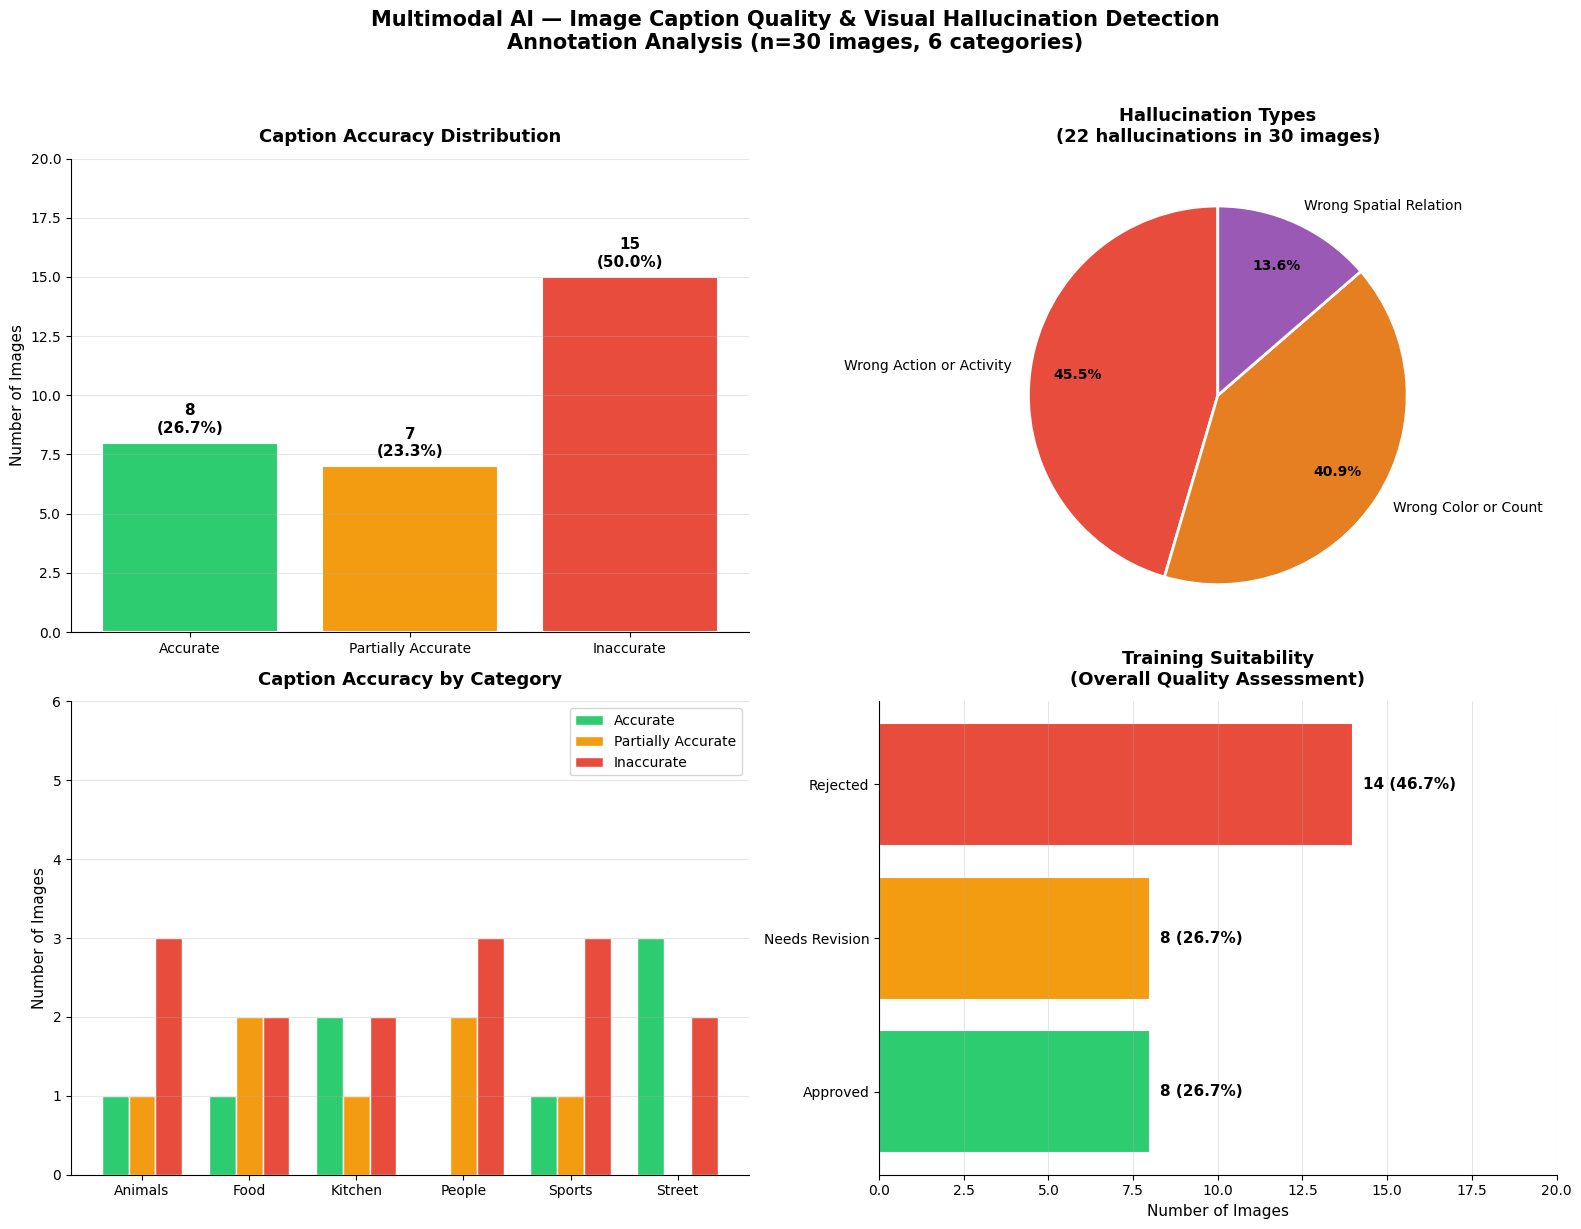

Charts saved successfully!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Multimodal AI — Image Caption Quality & Visual Hallucination Detection\nAnnotation Analysis (n=30 images, 6 categories)',
    fontsize=15, fontweight='bold', y=1.02
)

# ── Chart 1: Caption Accuracy Distribution ──
accuracy_order  = ['Accurate', 'Partially Accurate', 'Inaccurate']
accuracy_vals   = [accuracy_counts.get(a, 0) for a in accuracy_order]
accuracy_colors = ['#2ecc71', '#f39c12', '#e74c3c']

bars1 = axes[0,0].bar(
    accuracy_order, accuracy_vals,
    color=accuracy_colors, edgecolor='white', linewidth=1.5
)
axes[0,0].set_title('Caption Accuracy Distribution',
                     fontsize=13, fontweight='bold', pad=12)
axes[0,0].set_ylabel('Number of Images', fontsize=11)
axes[0,0].set_ylim(0, 20)
for bar, val in zip(bars1, accuracy_vals):
    pct = val / total * 100
    axes[0,0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)
axes[0,0].grid(axis='y', alpha=0.3)

# ── Chart 2: Hallucination Type Breakdown ──
hall_data   = hallucination_counts[hallucination_counts.index != 'None']
hall_colors = ['#e74c3c', '#e67e22', '#9b59b6']

wedges, texts, autotexts = axes[0,1].pie(
    hall_data.values,
    labels=hall_data.index,
    autopct='%1.1f%%',
    colors=hall_colors[:len(hall_data)],
    startangle=90,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

axes[0,1].set_title(
    f'Hallucination Types\n({total_hallucinations} hallucinations in {total} images)',
    fontsize=13, fontweight='bold', pad=12
)

# ── Chart 3: Accuracy by Category ──
categories  = sorted(df['category'].unique())
accurate_v  = [len(df[(df['category']==c) & (df['caption_accuracy']=='Accurate')]) for c in categories]
partial_v   = [len(df[(df['category']==c) & (df['caption_accuracy']=='Partially Accurate')]) for c in categories]
inaccurate_v= [len(df[(df['category']==c) & (df['caption_accuracy']=='Inaccurate')]) for c in categories]

x = np.arange(len(categories))
w = 0.25

bars_a = axes[1,0].bar(x - w, accurate_v,   w, label='Accurate',           color='#2ecc71', edgecolor='white')
bars_p = axes[1,0].bar(x,     partial_v,    w, label='Partially Accurate', color='#f39c12', edgecolor='white')
bars_i = axes[1,0].bar(x + w, inaccurate_v, w, label='Inaccurate',         color='#e74c3c', edgecolor='white')

axes[1,0].set_title('Caption Accuracy by Category',
                     fontsize=13, fontweight='bold', pad=12)
axes[1,0].set_ylabel('Number of Images', fontsize=11)
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels([c.capitalize() for c in categories], fontsize=10)
axes[1,0].legend(fontsize=10)
axes[1,0].set_ylim(0, 6)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)
axes[1,0].grid(axis='y', alpha=0.3)

# ── Chart 4: Training Suitability ──
quality_order  = ['Approved', 'Needs Revision', 'Rejected']
quality_vals   = [quality_counts.get(q, 0) for q in quality_order]
quality_colors = ['#2ecc71', '#f39c12', '#e74c3c']

bars4 = axes[1,1].barh(
    quality_order, quality_vals,
    color=quality_colors, edgecolor='white', linewidth=1.5
)
axes[1,1].set_title('Training Suitability\n(Overall Quality Assessment)',
                     fontsize=13, fontweight='bold', pad=12)
axes[1,1].set_xlabel('Number of Images', fontsize=11)
axes[1,1].set_xlim(0, 20)

for bar, val in zip(bars4, quality_vals):
    pct = val / total * 100
    axes[1,1].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'{val} ({pct:.1f}%)',
        va='center', fontsize=11, fontweight='bold'
    )
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)
axes[1,1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('caption_quality_analysis_charts.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Charts saved successfully!")

In [6]:
from google.colab import files

# Save main labeled dataset
df.to_csv('image_caption_labeled_dataset.csv', index=False)
print("Main dataset saved")

# Save hallucinations only
hallucinations_df = df[df['caption_accuracy'] != 'Accurate'].copy()
hallucinations_df.to_csv('image_caption_hallucinations.csv', index=False)
print(f"Hallucinations file saved: {len(hallucinations_df)} records")

# Save category summary
category_summary = df.groupby('category').agg(
    total=('image_id', 'count'),
    accurate=('caption_accuracy', lambda x: (x == 'Accurate').sum()),
    partially_accurate=('caption_accuracy', lambda x: (x == 'Partially Accurate').sum()),
    inaccurate=('caption_accuracy', lambda x: (x == 'Inaccurate').sum()),
    approved=('overall_quality', lambda x: (x == 'Approved').sum()),
    rejected=('overall_quality', lambda x: (x == 'Rejected').sum()),
    avg_seconds=('seconds_to_label', 'mean')
).round(1)
category_summary.to_csv('category_summary.csv')
print("Category summary saved")
print("\nCategory summary:")
print(category_summary.to_string())

# Download all files
print("\nDownloading files...")
files.download('caption_quality_analysis_charts.png')
files.download('image_caption_labeled_dataset.csv')
files.download('image_caption_hallucinations.csv')
files.download('category_summary.csv')
print("All files downloaded!")

Main dataset saved
Hallucinations file saved: 22 records
Category summary saved

Category summary:
          total  accurate  partially_accurate  inaccurate  approved  rejected  avg_seconds
category                                                                                  
animals       5         1                   1           3         1         3        131.6
food          5         1                   2           2         1         2         73.6
kitchen       5         2                   1           2         2         2         67.4
people        5         0                   2           3         0         3         53.8
sports        5         1                   1           3         1         2         99.0
street        5         3                   0           2         3         2         36.6



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
